In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp

pd.set_option('display.max_rows', None)     # tampilkan semua baris
pd.set_option('display.max_columns', None)  # tampilkan semua kolom
pd.set_option('display.width', None)        # biar nggak wrap otomatis
pd.set_option('display.max_colwidth', None) # biar kolom teks panjang tampil penuh

In [4]:

# Load dataset
path = 'train.csv'
events_path = 'events_train.csv'

match_data = pd.read_csv(path)
events_data = pd.read_csv(events_path)

C:\Users\sayyi\AppData\Local\Temp\ipykernel_28592\1995746726.py:6: DtypeWarning: Columns (24,38,52,58,59,60,61,62,63,64,65,69,70,71,72,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,99,100) have mixed types. Specify dtype option on import or set low_memory=False.
  events_data = pd.read_csv(events_path)


In [5]:
def missing_values_info(df,arr):
    for col in df:
        missing = events_data[col].isna().sum()
        arr.append([col, missing, (missing/len(events_data))*100])

In [7]:
# match dataset
missing_values = []
missing_values_info(match_data,missing_values)

index_output = list(range(0, len(missing_values)))
(pd.DataFrame(missing_values, columns=['Fitur', '# Missing','% Missing'], index=index_output).sort_values(by=['% Missing'], ascending=False, ignore_index=True))


KeyError: 'match_date'

In [8]:
def drop_cols_by_names (df, col_names):
    return df.drop(columns=col_names)

In [9]:
goalkeeper_cols = ['goalkeeper.success_out','goalkeeper.lost_out','shot.redirect','goalkeeper.lost_in_play','goalkeeper.success_in_play','goalkeeper.shot_saved_off_target','goalkeeper.shot_saved_to_post',
                   'goalkeeper.punched_out','goalkeeper.body_part.name','goalkeeper.technique.name','goalkeeper.outcome.name','goalkeeper.end_location','goalkeeper.position.name','goalkeeper.type.name']
passing_cols = ['pass.miscommunication','pass.deflected','pass.no_touch','pass.cut_back','pass.goal_assist','pass.outswinging','pass.inswinging','pass.through_ball','pass.aerial_won','pass.technique.name',
                'pass.shot_assist','pass.cross','pass.switch','pass.type.name','pass.outcome.name','pass.recipient.name','pass.body_part.name','pass.height.name','pass.angle','pass.end_location']
shoting_cols = ['shot.follows_dribble','shot.saved_off_target','shot.saved_to_post','shot.open_goal','shot.deflected','shot.aerial_won','shot.aerial_won','shot.first_time','shot.technique.name','shot.type.name',
                'shot.end_location','shot.body_part.name','shot.outcome.name']
dribble_cols = ['dribble.outcome.name','dribble.nutmeg','dribble.overrun','dribble.no_touch']


In [14]:
high_col_percent_missing =['goalkeeper.success_out','goalkeeper.lost_out','goalkeeper.lost_in_play','shot.saved_off_target','shot.follows_dribble','shot.saved_off_target','goalkeeper.shot_saved_off_target','goalkeeper.punched_out','dribble.no_touch','pass.cut_back','pass.outswinging',
                           'substitution.replacement.name','substitution.outcome.name',
                           'goalkeeper.body_part.name','goalkeeper.technique.name','out','shot.body_part.name',
                           'pass.recipient.name','pass.body_part.name','pass.height.name','off_camera','shot.first_time','shot.redirect','shot.follows_dribble',
                           'dribble.nutmeg','dribble.overrun','dribble.no_touch','clearance.other','injury_stoppage.in_chain','goalkeeper.position.name',
                           'goalkeeper.type.name','timestamp','type.name','duel.type.name','pass.type.name','id','player.name','related_events','possession_team.name',
                           'play_pattern.name','location','pass.angle','pass.end_location','shot.end_location','shot.technique.name','pass.technique.name',
                           'shot.type.name','shot.deflected','pass.shot_assist','pass.cross','pass.switch','pass.through_ball','pass.aerial_won','pass.miscommunication','pass.deflected','pass.no_touch']

copied_df = drop_cols_by_names(events_data, high_col_percent_missing)

missing_values = []
missing_values_info(copied_df,missing_values)

index_output = list(range(0, len(missing_values)))
(pd.DataFrame(missing_values, columns=['Fitur', '# Missing','% Missing'], index=index_output).sort_values(by=['% Missing'], ascending=False, ignore_index=True))
 


,Fitur,# Missing,% Missing
0,player_off.permanent,328674,99.999696
1,goalkeeper.success_in_play,328673,99.999391
2,shot.saved_to_post,328669,99.998174
3,goalkeeper.shot_saved_to_post,328668,99.997870
4,block.save_block,328662,99.996045
5,ball_recovery.offensive,328651,99.992698
6,pass.straight,328638,99.988743
7,block.offensive,328624,99.984483
8,miscontrol.aerial_won,328608,99.979615
9,foul_committed.offensive,328591,99.974443


In [15]:
copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
team.name                          object
under_pressure                      int64
carry.end_location                 object
dribble.outcome.name               object
duel.outcome.name                  object
50_50.outcome.name                 object
shot.outcome.name                  object
goalkeeper.end_location            object
pass.outcome.name                  object
ball_receipt.outcome.name          object
counterpress                        int64
clearance.left_foot                 int64
clearance.body_part.name           object
clearance.right_foot                int64
clearance.head                      int64
foul_won.defensive                 object
interception.outcome.name          object
goalkeeper.outcome.name            object
ball_recovery.recovery_failure     object
clearance.aerial_won              

In [16]:
bool_cols = [
    'under_pressure', 'counterpress', 'pass.switch', 'pass.cross', 'pass.goal_assist',
    'pass.shot_assist', 'shot.first_time', 'shot.open_goal', 'shot.one_on_one',
    'clearance.left_foot', 'clearance.right_foot', 'clearance.head',
    'foul_committed.penalty', 'foul_won.penalty'
]

for col in bool_cols:
    events_data[col] = events_data[col].apply(lambda x: 1 if x == True or x == 'TRUE' else 0)

copied_df.dtypes

index                               int64
period                              int64
possession                          int64
duration                          float64
team.name                          object
under_pressure                      int64
carry.end_location                 object
dribble.outcome.name               object
duel.outcome.name                  object
50_50.outcome.name                 object
shot.outcome.name                  object
goalkeeper.end_location            object
pass.outcome.name                  object
ball_receipt.outcome.name          object
counterpress                        int64
clearance.left_foot                 int64
clearance.body_part.name           object
clearance.right_foot                int64
clearance.head                      int64
foul_won.defensive                 object
interception.outcome.name          object
goalkeeper.outcome.name            object
ball_recovery.recovery_failure     object
clearance.aerial_won              

In [98]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['shot.outcome.name', 'pass.outcome.name', 'duel.outcome.name','dribble.outcome.name',
            'interception.outcome.name','block.save_block','goalkeeper.shot_saved_to_post','goalkeeper.outcome.name']
le = LabelEncoder()
for col in cat_cols:
    copied_df[col] = copied_df[col].astype(str).fillna('Unknown')
    copied_df[col] = le.fit_transform(copied_df[col])

copied_df.dtypes


index                               int64
period                              int64
possession                          int64
duration                          float64
team.name                          object
under_pressure                      int64
carry.end_location                 object
dribble.outcome.name                int64
duel.outcome.name                   int64
50_50.outcome.name                 object
shot.outcome.name                   int64
goalkeeper.end_location            object
pass.outcome.name                   int64
ball_receipt.outcome.name          object
counterpress                        int64
clearance.left_foot                 int64
clearance.body_part.name           object
clearance.right_foot                int64
clearance.head                      int64
foul_won.defensive                 object
interception.outcome.name           int64
goalkeeper.outcome.name             int64
ball_recovery.recovery_failure     object
clearance.aerial_won              

In [ ]:
copied_df.shape

(328675, 48)

In [ ]:
copied_df.tail(100)

In [18]:

goal_assist = copied_df["dribble.outcome.name"].dropna().values
stats = [
    ['Mean', np.mean(goal_assist)],
    ['Median', np.median(goal_assist)],
    ['Range', np.max(goal_assist) - np.min(goal_assist)],
    ['IQR', scp.iqr(goal_assist)],
    ['Variance', np.var(goal_assist)],
    ['Standard Deviation', np.std(goal_assist)],
]
pd.DataFrame(stats, columns=['Measure', 'Value'])

,Measure,Value
0,Mean,1.985785
1,Median,2.000000
2,Range,2.000000
3,IQR,0.000000
4,Variance,0.024521
5,Standard Deviation,0.156593


In [19]:
open_goal = copied_df["shot.open_goal"]
stats = [
    ['Mean', np.mean(open_goal)],
    ['Median', np.median(open_goal)],
    ['Range', np.max(open_goal) - np.min(open_goal)],
    ['IQR', scp.iqr(open_goal)],
    ['Variance', np.var(open_goal)],
    ['Standard Deviation', np.std(open_goal)],
]
pd.DataFrame(stats, columns=['Measure', 'Value'])

,Measure,Value
0,Mean,0.000073
1,Median,0.000000
2,Range,1.000000
3,IQR,0.000000
4,Variance,0.000073
5,Standard Deviation,0.008545


In [ ]:
possesion = copied_df["possession"]
stats = [
    ['Mean', np.mean(possesion)],
    ['Median', np.median(possesion)],
    ['Range', np.max(possesion) - np.min(possesion)],
    ['IQR', scp.iqr(possesion)],
    ['Variance', np.var(possesion)],
    ['Standard Deviation', np.std(possesion)],
]
pd.DataFrame(stats, columns=['Measure', 'Value'])

,Measure,Value
0,Mean,88.626665
1,Median,87.000000
2,Range,227.000000
3,IQR,90.000000
4,Variance,2859.711556
5,Standard Deviation,53.476271


### Melakukan understanding data terhadap dataset events

In [99]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(events_data[col].value_counts())
    print()

Value counts for shot.outcome.name:
shot.outcome.name
Off T               648
Saved               549
Blocked             511
Goal                274
Wayward              82
Post                 48
Saved to Post         6
Saved Off Target      6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
Incomplete          12680
Out                  1229
Unknown               410
Pass Offside          343
Injury Clearance       79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
Success In Play    1001
Won                 717
Lost In Play        579
Lost Out            443
Success Out         100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
Complete      1727
Incomplete    1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
Won                795
Success In Play    509
Lost In Play       449
Lost Out           226
Success Out         10
Name:

In [100]:
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(copied_df[col].value_counts())
    print()

15,12,9,1,0,11,14

Value counts for shot.outcome.name:
shot.outcome.name
8    326551
2       648
4       549
0       511
1       274
7        82
3        48
6         6
5         6
Name: count, dtype: int64

Value counts for pass.outcome.name:
pass.outcome.name
5    313934
0     12680
2      1229
4       410
3       343
1        79
Name: count, dtype: int64

Value counts for duel.outcome.name:
duel.outcome.name
5    325835
2      1001
4       717
0       579
1       443
3       100
Name: count, dtype: int64

Value counts for dribble.outcome.name:
dribble.outcome.name
2    325730
0      1727
1      1218
Name: count, dtype: int64

Value counts for interception.outcome.name:
interception.outcome.name
5    326686
4       795
2       509
0       449
1       226
3        10
Name: count, dtype: int64

Value counts for block.save_block:
block.save_block
1    328662
0        13
Name: count, dtype: int64

Value counts for goalkeeper.shot_saved_to_post:
goalkeeper.shot_saved_to_post
1    328668
0         7
Name: co

In [106]:
# buat colomn baru untuk ambil yang valuenya positif saja
copied_df['dribble.successful'] = copied_df['dribble.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['shot.outcome.goal'] = copied_df['shot.outcome.name'].apply(lambda x: 1 if x == 1 else 0)
copied_df['interception.outcome.positive'] = copied_df['interception.outcome.name'].apply(lambda x: 1 if x == 2 or x == 4 else 0)
copied_df['goalkeeper.outcome.positive'] = copied_df['goalkeeper.outcome.name'].apply(lambda x: 1 if x in [15,12,9,1,0,11,14] else 0)
copied_df['total_clearance'] = copied_df[['clearance.left_foot', 'clearance.right_foot', 'clearance.head']].sum(axis=1)

#### feature engineering sebelum merge

In [107]:

aggregated_features = copied_df.groupby('match_id').agg({
    # Durasi & Possession
    'duration': ['mean', 'sum', 'std'],
    'possession': ['max', 'mean'],
    
    # Pressure & Counterpress
    'under_pressure': 'sum',
    'counterpress': 'sum',
    
    # Passing features (sudah di-encode di copied_df)
    'pass.inswinging': 'sum',
    'pass.outcome.name': lambda x: (x == 0).sum() if len(x) > 0 else 0,  # successful passes
    
    # Shooting features (sudah di-encode di copied_df)
    'shot.open_goal': 'sum',
    
    # Dribble features (ambil yang valuenya 0 saja)
    'dribble.outcome.name': lambda x: (x == 0).sum() if len(x) > 0 else 0,  # successful dribbles
    
    # Clearance features
    'total_clearance': 'sum',
    
    # Fouls
    'foul_committed.penalty': 'sum',
    'foul_won.penalty': 'sum',
    
    # Duel (sudah di-encode di copied_df)
    'duel.outcome.positive': 'sum',

    # interception (sudah di-encode di copied_df)
    'interception.outcome.positive': 'sum',

    # goalkeeper (sudah di-encode di copied_df)
    'goalkeeper.outcome.positive': 'sum',
    
    # Period
    'period': 'max'  # berapa periode dimainkan
}).reset_index()

# Flatten column names
aggregated_features.columns = ['_'.join(col).strip('_') for col in aggregated_features.columns.values]

ev = events_data.copy()

# tanda goal: cek kolom teks dulu
if 'shot.outcome.name' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.name'].astype(str).str.contains('goal', case=False, na=False).astype(int)
elif 'shot.outcome.goal' in ev.columns:
    ev['shot_goal_flag'] = ev['shot.outcome.goal'].fillna(0).astype(int)
else:
    ev['shot_goal_flag'] = 0

# cari kolom team yang tersedia
team_candidates = ['possession_team.name', 'team.name', 'team', 'possession_team']
team_col = next((c for c in team_candidates if c in ev.columns), None)

if team_col is None:
    print("Warning: team column not found in events_data — cannot compute Barcelona goals per match.")
    aggregated_features['shot.outcome.goal.barca'] = 0
    aggregated_features['shot.outcome.goal.nonbarca'] = 0
    aggregated_features['dribble.outcome.completed'] = 0
else:
    ev['is_barca'] = ev[team_col].astype(str).str.contains('barcelona', case=False, na=False)
    ev['is_nonbarca'] = ~ev['is_barca']

    # for barca goals
    barca_goals_per_match = ev.loc[ev['is_barca'] & (ev['shot_goal_flag'] == 1)].groupby('match_id')['shot_goal_flag'].sum()
    barca_goals_per_match.name = 'shot.outcome.goal.barca'

    # for non-barca goals
    nonbarca_goals_per_match = ev.loc[ev['is_nonbarca'] & (ev['shot_goal_flag'] == 1)].groupby('match_id')['shot_goal_flag'].sum()
    nonbarca_goals_per_match.name = 'shot.outcome.goal.nonbarca'

    aggregated_features = aggregated_features.merge(barca_goals_per_match.reset_index(), on='match_id', how='left')
    aggregated_features['shot.outcome.goal.barca'] = aggregated_features['shot.outcome.goal.barca'].fillna(0).astype(int)

    aggregated_features = aggregated_features.merge(nonbarca_goals_per_match.reset_index(), on='match_id', how='left')
    aggregated_features['shot.outcome.goal.nonbarca'] = aggregated_features['shot.outcome.goal.nonbarca'].fillna(0).astype(int)

In [ ]:

df_merged = match_data.merge(
    aggregated_features, 
    on='match_id', 
    how='left'  # LEFT JOIN 
)

print("=" * 60)
print("HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES")
print("=" * 60)
print(f"Match data shape: {match_data.shape}")
print(f"Aggregated features shape: {aggregated_features.shape}")
print(f"Merged data shape: {df_merged.shape}")

df_merged.head(100)

HASIL MERGE MATCH_DATA + AGGREGATED_FEATURES
Match data shape: (85, 18)
Aggregated features shape: (85, 21)
Merged data shape: (85, 38)


,match_id,match_date,kick_off,home_score,away_score,match_week,home_team.home_team_name,away_team.away_team_name,stadium.name,referee.name,home_team.managers_name,home_team.managers_country,home_team.managers_dob,away_team.managers_name,away_team.managers_country,away_team.managers_dob,Poss,Result,duration_mean,duration_sum,duration_std,possession_max,possession_mean,under_pressure_sum,counterpress_sum,pass.inswinging_sum,pass.outcome.name_<lambda>,shot.open_goal_sum,dribble.outcome.name_<lambda>,total_clearance_sum,foul_committed.penalty_sum,foul_won.penalty_sum,duel.outcome.positive_sum,interception.outcome.positive_sum,goalkeeper.outcome.positive_sum,period_max,shot.outcome.goal.barca,shot.outcome.goal.nonbarca
0,9742,2018-01-07,16:15:00.000,3,0,18,Barcelona,Levante UD,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Juan Ramón López Muñiz,Spain,1968-11-02,29.0,Win,1.167503,3218.806797,1.239217,174,90.208658,788,105,2,118,0,21,29,0,0,20,26,10,2,3,0
1,9754,2018-01-14,20:45:00.000,2,4,19,Real Sociedad,Barcelona,Reale Arena,José Luis González González,Eusebio Sacristán Mena,Spain,1964-04-13,Ernesto Valverde Tejedor,Spain,1964-02-09,50.0,Lose,1.269414,3521.353494,1.248567,189,91.610629,927,105,3,140,0,19,27,0,0,10,15,7,2,4,2
2,9765,2018-01-21,20:45:00.000,0,5,20,Real Betis,Barcelona,Estadio Benito Villamarín,NaN,Eder Sarabia Armesto,Spain,1981-01-12,Ernesto Valverde Tejedor,Spain,1964-02-09,52.0,Lose,1.251360,3606.420428,1.343604,194,90.744054,819,102,0,156,0,23,13,0,0,16,23,8,2,5,0
3,9774,2018-01-28,20:45:00.000,2,1,21,Barcelona,Deportivo Alavés,Spotify Camp Nou,Ignacio Iglesias Villanueva,Ernesto Valverde Tejedor,Spain,1964-02-09,Abelardo Fernández Antuña,Spain,1970-04-19,23.0,Win,1.290555,3315.434749,1.370656,211,103.305611,608,119,6,173,0,27,48,0,0,23,25,10,2,2,1
4,9783,2018-02-04,16:15:00.000,1,1,22,Espanyol,Barcelona,RCDE Stadium,Jesús Gil Manzano,Enrique Sánchez Flores,Spain,1965-02-05,Ernesto Valverde Tejedor,Spain,1964-02-09,72.0,Draw,1.124281,2769.104961,1.238528,186,90.246093,602,122,3,182,0,19,48,0,0,26,22,5,2,1,1
5,9794,2018-02-11,16:15:00.000,0,0,23,Barcelona,Getafe,Spotify Camp Nou,David Fernández Borbalan,Ernesto Valverde Tejedor,Spain,1964-02-09,José Bordalás Jiménez,Spain,1964-03-05,21.0,Draw,1.297259,3379.359291,1.383268,162,69.754749,513,99,4,185,0,15,21,0,0,16,38,13,2,0,0
6,9799,2018-02-17,16:15:00.000,0,2,24,Eibar,Barcelona,Estadio Municipal de Ipurúa,Alejandro José Hernández Hernández,José Luis Mendilibar Etxebarria,Spain,1961-03-14,Ernesto Valverde Tejedor,Spain,1964-02-09,54.0,Lose,1.280193,3468.043543,1.348531,208,106.373461,665,102,0,188,0,16,33,0,0,24,34,7,2,2,0
7,9811,2018-02-24,20:45:00.000,6,1,25,Barcelona,Girona,Spotify Camp Nou,NaN,Ernesto Valverde Tejedor,Spain,1964-02-09,Pablo Javier Machín Díez,Spain,1975-04-07,38.0,Win,1.252455,3261.393962,1.321908,177,90.548023,622,108,3,146,0,22,25,0,0,19,21,14,2,7,0
8,9827,2018-03-01,21:00:00.000,1,1,26,Las Palmas,Barcelona,Estadio de Gran Canaria,Antonio Miguel Mateu Lahoz,Francisco Jémez Martín,Spain,1970-04-18,Ernesto Valverde Tejedor,Spain,1964-02-09,64.0,Draw,1.251634,3091.536839,1.336224,188,98.993401,657,89,6,142,0,27,28,1,0,28,12,9,2,1,1
9,9837,2018-03-04,16:15:00.000,1,0,27,Barcelona,Atlético Madrid,Spotify Camp Nou,Jesús Gil Manzano,Ernesto Valverde Tejedor,Spain,1964-02-09,Diego Pablo Simeone,Argentina,1970-04-28,42.0,Win,1.094074,3234.083318,1.158413,214,105.142677,643,156,6,175,0,33,23,0,0,31,28,10,2,1,0


In [109]:
# Cek struktur data
print("Events data shape:", copied_df.shape)
print("\nMatch data shape:", match_data.shape)
print("\nEvents columns:", copied_df.columns.tolist()[:20])  # show first 20
print("\nMatch columns:", match_data.columns.tolist())

Events data shape: (328675, 54)

Match data shape: (85, 18)

Events columns: ['index', 'period', 'possession', 'duration', 'team.name', 'under_pressure', 'carry.end_location', 'dribble.outcome.name', 'duel.outcome.name', '50_50.outcome.name', 'shot.outcome.name', 'goalkeeper.end_location', 'pass.outcome.name', 'ball_receipt.outcome.name', 'counterpress', 'clearance.left_foot', 'clearance.body_part.name', 'clearance.right_foot', 'clearance.head', 'foul_won.defensive']

Match columns: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_week', 'home_team.home_team_name', 'away_team.away_team_name', 'stadium.name', 'referee.name', 'home_team.managers_name', 'home_team.managers_country', 'home_team.managers_dob', 'away_team.managers_name', 'away_team.managers_country', 'away_team.managers_dob', 'Poss', 'Result']


#### Bagaimanakah pola defensif tim Barcelona dari tahun ke tahun, apakah ada penyesuaian pola jika menghadapi tim-tim tertentu?

Detected defensive-related columns: ['total_clearance_sum', 'duel.outcome.positive_sum', 'interception.outcome.positive_sum', 'goalkeeper.outcome.positive_sum', 'shot.outcome.goal.nonbarca']

Average defensive metrics per year:


,total_clearance_sum,duel.outcome.positive_sum,interception.outcome.positive_sum,goalkeeper.outcome.positive_sum,shot.outcome.goal.nonbarca
year,,,,,
2018,30.852941,21.588235,18.558824,7.911765,0.941176
2019,34.774194,19.645161,12.483871,7.000000,0.903226
2020,37.076923,19.076923,13.153846,6.153846,1.076923
2021,29.285714,18.142857,16.428571,6.142857,0.571429


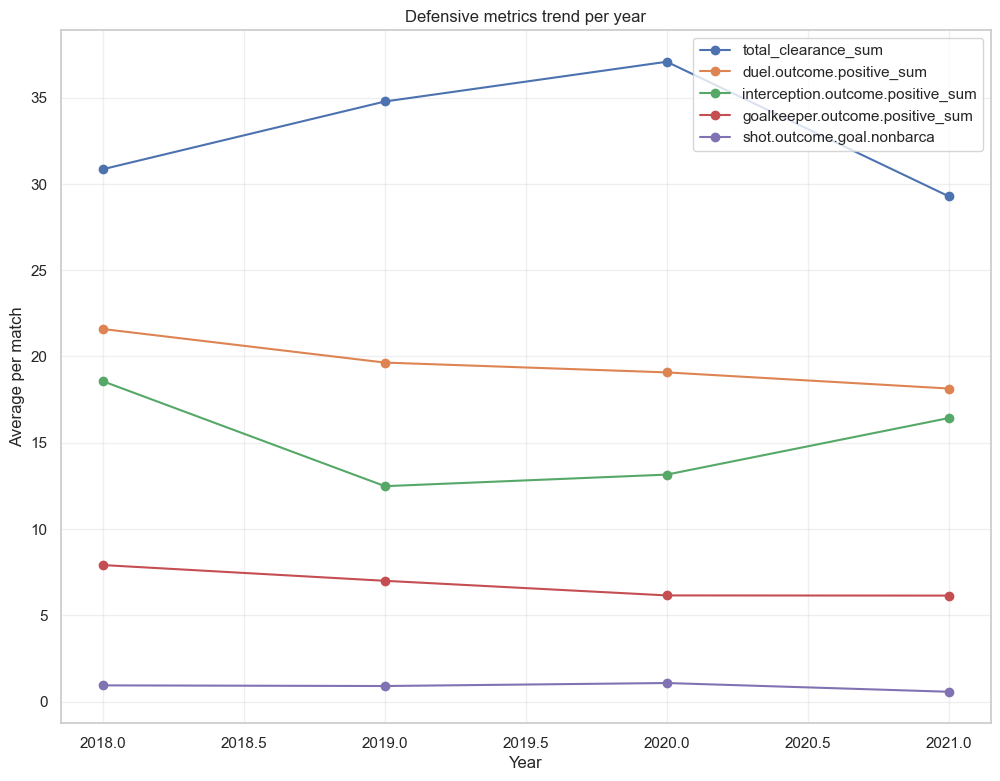

In [110]:
# Gunakan proxy defensive: duel counts, clearances, fouls

defensive_features = [c for c in df_merged.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
print('Detected defensive-related columns:', defensive_features[:20])

if defensive_features:
    df_merged['match_date'] = pd.to_datetime(df_merged['match_date'])
    df_merged['year'] = df_merged['match_date'].dt.year
    def_summary = df_merged.groupby('year')[defensive_features].mean()
    print('\nAverage defensive metrics per year:')
    display(def_summary)

    # Plot trends for first few defensive metrics
    to_plot = defensive_features[:9]
    if to_plot:
        plt.figure(figsize=(12,9))
        for c in to_plot:
            if c in def_summary.columns:
                plt.plot(def_summary.index, def_summary[c], marker='o', label=c)
        plt.legend()
        plt.title('Defensive metrics trend per year')
        plt.xlabel('Year')
        plt.ylabel('Average per match')
        plt.grid(alpha=0.3)
        plt.show()
else:
    print('Tidak ditemukan kolom defensif yang jelas di df_merged. Pastikan aggregated defensive features dibuat saat agregasi events.')

In [ ]:

# 1) Fokus hanya pertandingan Barcelona
barca_mask = (
    df_merged['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False) |
    df_merged['away_team.away_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
)
df_barca = df_merged.loc[barca_mask].copy()
if df_barca.empty:
    print("Tidak ada match Barcelona ditemukan di df_merged.")
else:
    # 2) Tentukan lawan dan apakah Barca main kandang
    df_barca['barca_is_home'] = df_barca['home_team.home_team_name'].astype(str).str.contains('barcelona', case=False, na=False)
    df_barca['opponent'] = np.where(df_barca['barca_is_home'], df_barca['away_team.away_team_name'], df_barca['home_team.home_team_name'])
    df_barca['opponent'] = df_barca['opponent'].fillna('Unknown')

    # 3) Defensive columns (gunakan fitur agregat defensif yang sudah dibuat)
    defensive_cols = [c for c in df_barca.columns if any(k in c for k in ['duel','clearance','tackle','interception','conceded','nonbarca','goalkeeper'])]
    if not defensive_cols:
        print("Tidak ditemukan kolom defensif di df_merged. Pastikan agregasi defensif dibuat sebelumnya.")
    else:
        print("Defensive columns detected:", defensive_cols)

        # 4) Ringkasan per opponent
        opp_summary = df_barca.groupby('opponent')[defensive_cols].agg(['mean','std','count'])
        # tampilkan top opponent berdasarkan jumlah match
        opp_counts = opp_summary[ (defensive_cols[0],'count') ].sort_values(ascending=False)
        top_opponents = opp_counts.head(30).index.tolist()
        print("\nTop opponents by matches (top 30):")
        display(opp_counts.head(30))

        print("\nDefensive summary (mean) for top opponents:")
        display(opp_summary.loc[top_opponents].xs('mean', level=1, axis=1).sort_values(by=defensive_cols[0], ascending=False))

        # 5) Visualisasi: bar chart defensive metric per opponent (top N)
        import matplotlib.pyplot as plt
        import seaborn as sns
        sns.set(style="whitegrid")

        top_n = top_opponents[:30]
        metrics_to_plot = defensive_cols[:4]  # pilih beberapa metric defensif utama
        for metric in metrics_to_plot:
            plt.figure(figsize=(10,5))
            vals = df_barca.groupby('opponent')[metric].mean().loc[top_n].fillna(0)
            vals.sort_values(ascending=False).plot(kind='bar')
            plt.title(f"Average {metric} vs Opponent (Barcelona matches) - top {len(top_n)} opponents")
            plt.ylabel(f"Average {metric}")
            plt.xlabel("Opponent")
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

        # 6) Trend per year untuk top opponents (lihat apakah ada adjustment)
        df_barca['match_date'] = pd.to_datetime(df_barca['match_date'], errors='coerce')
        df_barca['year'] = df_barca['match_date'].dt.year.fillna(0).astype(int)
        years = sorted(df_barca['year'].unique())

        for metric in metrics_to_plot:
            plt.figure(figsize=(10,6))
            for opp in top_n:
                series = df_barca[df_barca['opponent']==opp].groupby('year')[metric].mean().reindex(years)
                if series.notna().sum() > 0:
                    plt.plot(series.index, series.values, marker='o', label=opp)
            plt.title(f"Yearly trend of {metric} vs top opponents")
            plt.xlabel("Year")
            plt.ylabel(metric)
            plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        # 7) Optional: statistik — apakah metric melawan satu opponent berbeda signifikan dari rata-rata?
        from scipy.stats import ttest_ind
        metric_for_test = defensive_cols[0]
        overall = df_barca[metric_for_test].dropna()
        print(f"\nT-tests comparing {metric_for_test} per top opponent vs overall:")
        for opp in top_n:
            group = df_barca[df_barca['opponent']==opp][metric_for_test].dropna()
            if len(group) >= 3 and len(overall) >= 3:
                stat, p = ttest_ind(group, overall, equal_var=False)
                print(f"{opp}: n={len(group)} mean={group.mean():.3f} p={p:.4f}")
            else:
                print(f"{opp}: not enough data for test (n={len(group)})")


In [114]:
# === Tentukan gaya permainan (playstyle) per tahun — clustering heuristic ===
# Gunakan fitur agregat proxy: Poss, total shots, pass goal assists, under_pressure

# select candidate features (proxies)
candidates = []
for f in ['Poss', 'shot.outcome.name_count', 'pass.goal_assist_sum', 'under_pressure_sum', 'possession_max', 'duration_mean']:
    if f in df_merged.columns:
        candidates.append(f)

print('Candidate features for playstyle clustering:', candidates)

if len(candidates) >= 2:
    from sklearn.cluster import KMeans
    use_df = df_merged[candidates].fillna(0)
    # standardize
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(use_df)

    # try 3 clusters (can be adjusted)
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X)
    df_merged['play_cluster'] = clusters

    # Inspect cluster centers in original scale
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    centers_df = pd.DataFrame(centers, columns=candidates)
    print('\nCluster centers (proxy features):')
    display(centers_df)

    # Describe clusters and decide labels heuristically
    cluster_summary = df_merged.groupby('play_cluster')[candidates].mean()
    print('\nAverage feature values per cluster:')
    display(cluster_summary)

    # Heuristic labeling: choose labels based on possession and shots
    cluster_labels = {}
    for idx, row in cluster_summary.iterrows():
        if ('Poss' in row.index and row['Poss'] >= 60) or ('possession_max' in row.index and row.get('possession_max',0) >= 60):
            cluster_labels[idx] = 'Possession Game'
        elif ('pass.goal_assist_sum' in row.index and row.get('pass.goal_assist_sum',0) > 0.5):
            cluster_labels[idx] = 'Wide/Passing'
        else:
            cluster_labels[idx] = 'Counter/Direct'

    df_merged['playstyle_label'] = df_merged['play_cluster'].map(cluster_labels)
    print('\nAssigned playstyle labels:', cluster_labels)

    # Majority playstyle per year
    df_merged['match_date'] = pd.to_datetime(df_merged['match_date'])
    df_merged['year'] = df_merged['match_date'].dt.year
    play_by_year = df_merged.groupby('year')['playstyle_label'].agg(lambda x: x.value_counts().idxmax() if len(x)>0 else None)
    print('\nMajority playstyle per year:')
    display(play_by_year)
else:
    print('Tidak ada cukup fitur proxy untuk clustering playstyle. Tambahkan aggregated features seperti possession, shot counts, pass assists.')

Candidate features for playstyle clustering: ['Poss', 'under_pressure_sum', 'possession_max', 'duration_mean']

Cluster centers (proxy features):

Cluster centers (proxy features):


,Poss,under_pressure_sum,possession_max,duration_mean
0,40.888889,782.166667,195.194444,1.254180
1,45.434783,586.608696,165.913043,1.277585
2,61.884615,742.230769,175.500000,1.196540



Average feature values per cluster:


,Poss,under_pressure_sum,possession_max,duration_mean
play_cluster,,,,
0,40.888889,782.166667,195.194444,1.254180
1,45.434783,586.608696,165.913043,1.277585
2,61.884615,742.230769,175.500000,1.196540



Assigned playstyle labels: {0: 'Possession Game', 1: 'Possession Game', 2: 'Possession Game'}

Majority playstyle per year:


year
2018    Possession Game
2019    Possession Game
2020    Possession Game
2021    Possession Game
Name: playstyle_label, dtype: object

Defensive columns detected: ['clearance.left_foot_sum', 'clearance.right_foot_sum', 'clearance.head_sum', 'duel.outcome.positive_sum', 'interception.outcome.positive_sum', 'goalkeeper.outcome.positive_sum', 'shot.outcome.goal.nonbarca']

Top opponents by matches (top 20):


opponent
Athletic Club       4
Atlético Madrid     4
Celta Vigo          4
Deportivo Alavés    4
Eibar               4
Espanyol            4
Getafe              4
Levante UD          4
Leganés             4
Granada             4
Villarreal          4
Sevilla             4
Real Madrid         4
Valencia            4
Real Valladolid     4
Real Sociedad       4
Real Betis          4
Girona              3
Huesca              3
Osasuna             3
Name: (clearance.left_foot_sum, count), dtype: int64


Defensive summary (mean) for top opponents:


,clearance.left_foot_sum,clearance.right_foot_sum,clearance.head_sum,duel.outcome.positive_sum,interception.outcome.positive_sum,goalkeeper.outcome.positive_sum,shot.outcome.goal.nonbarca
opponent,,,,,,,
Eibar,10.250000,9.500000,24.250000,17.000000,18.750000,7.000000,0.500000
Espanyol,10.000000,10.250000,17.250000,26.250000,18.250000,5.250000,0.750000
Villarreal,8.750000,7.500000,9.750000,20.250000,10.500000,6.500000,1.750000
Osasuna,8.666667,10.333333,21.000000,16.333333,14.333333,6.333333,0.666667
Leganés,8.250000,11.250000,12.000000,25.750000,11.250000,6.000000,1.250000
Huesca,7.666667,8.000000,12.333333,20.000000,12.333333,6.000000,1.000000
Valencia,7.500000,12.000000,18.500000,20.000000,12.250000,7.500000,1.500000
Deportivo Alavés,7.250000,11.250000,16.750000,16.500000,16.000000,7.750000,0.500000
Getafe,7.250000,8.750000,15.500000,20.500000,20.250000,5.500000,0.500000


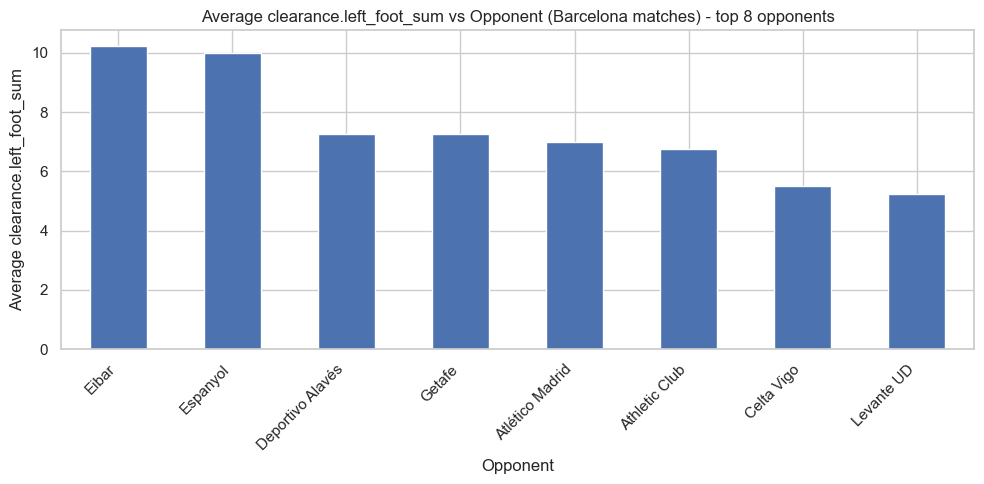

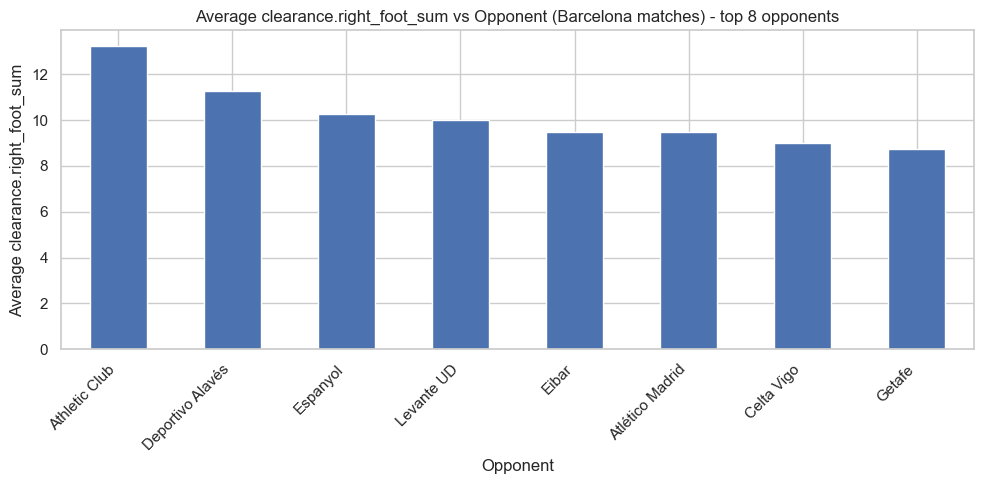

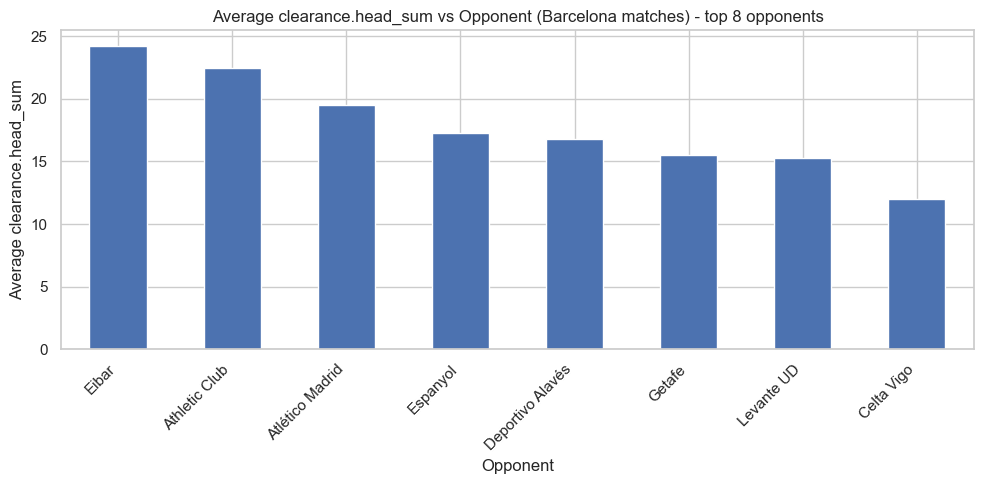

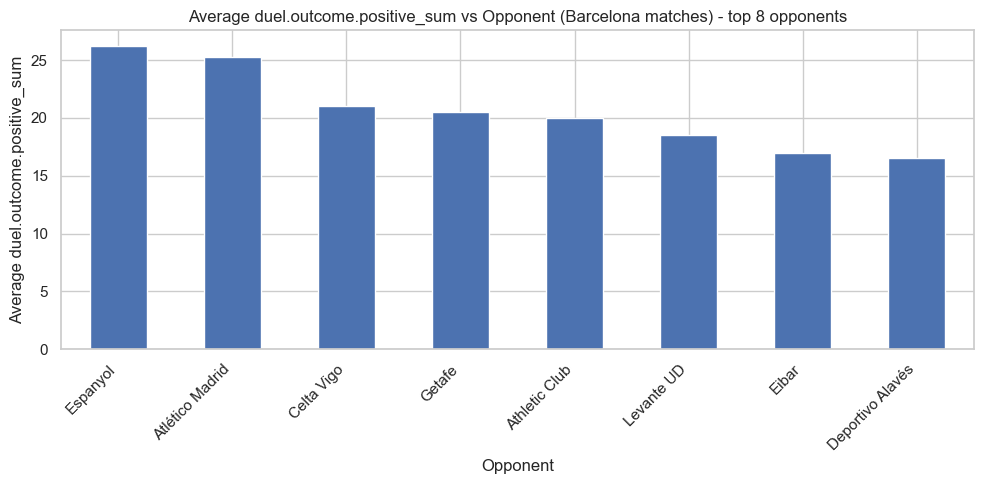

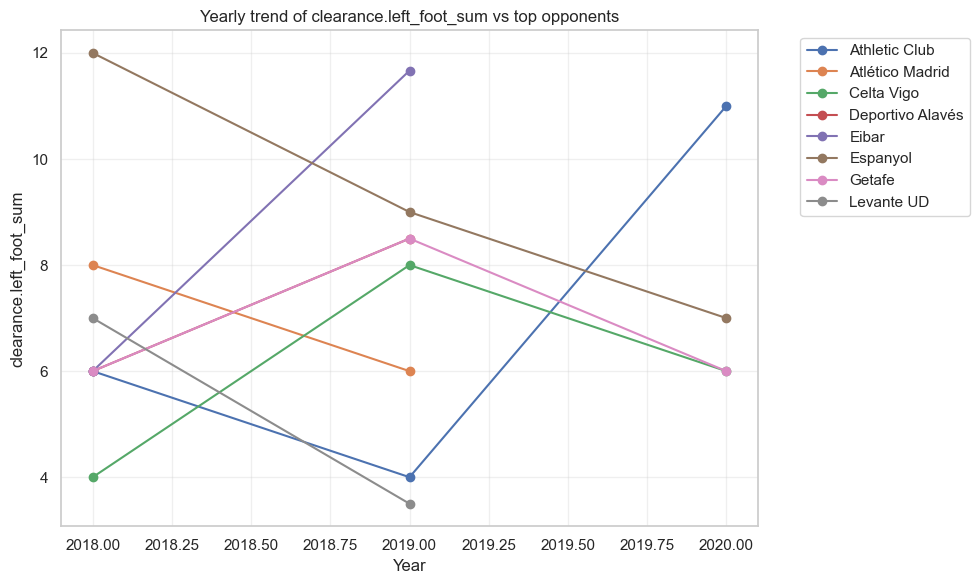

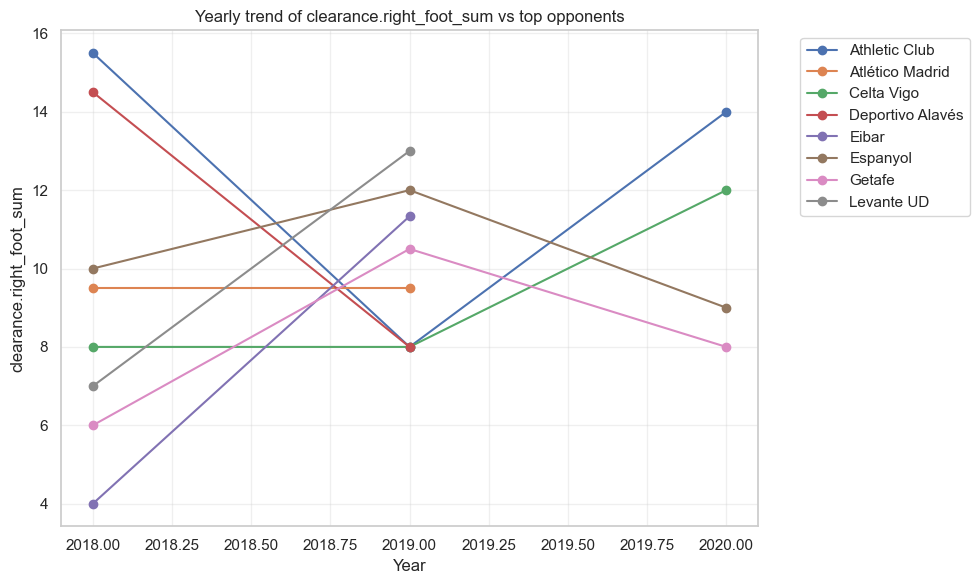

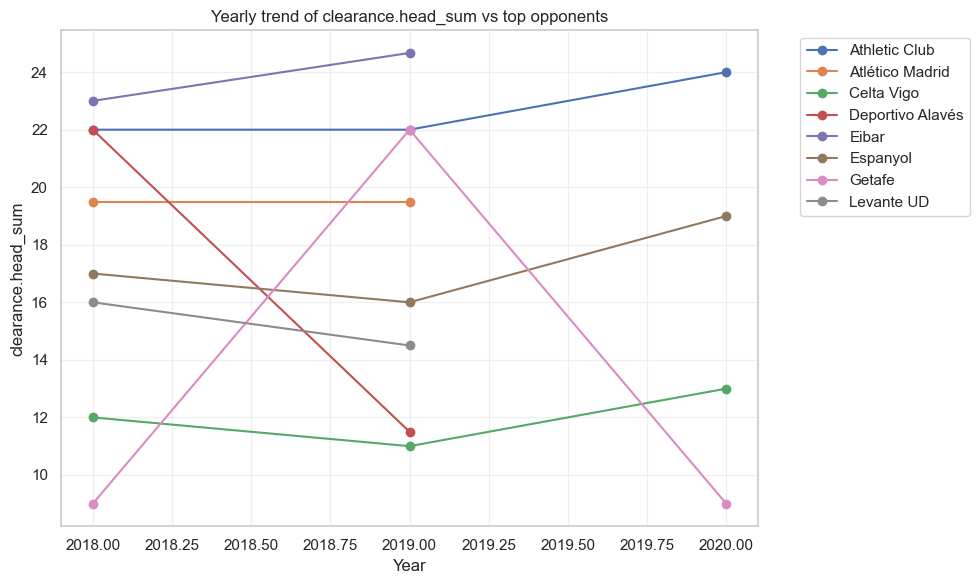

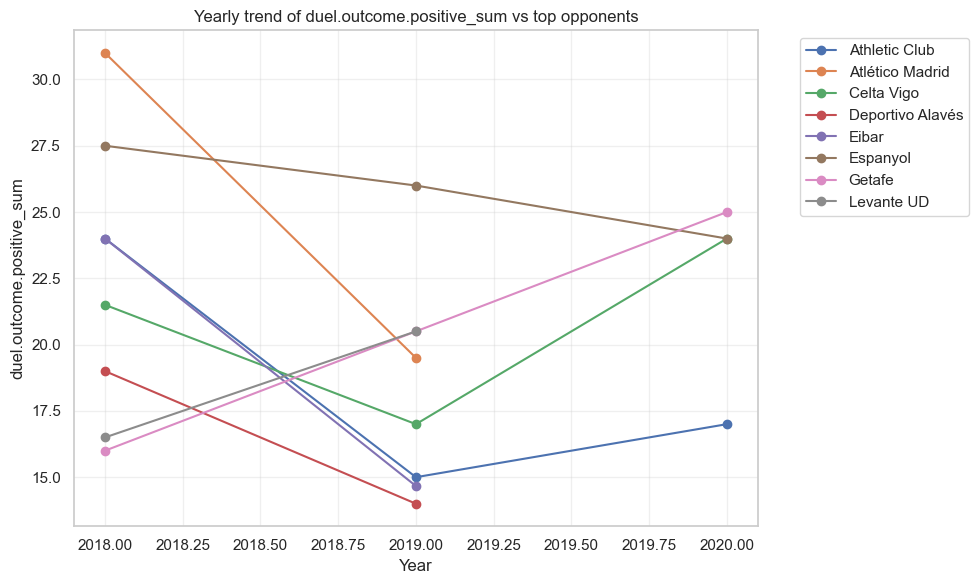


T-tests comparing clearance.left_foot_sum per top opponent vs overall:
Athletic Club: n=4 mean=6.750 p=0.9736
Atlético Madrid: n=4 mean=7.000 p=0.9041
Celta Vigo: n=4 mean=5.500 p=0.3784
Deportivo Alavés: n=4 mean=7.250 p=0.7649
Eibar: n=4 mean=10.250 p=0.1352
Espanyol: n=4 mean=10.000 p=0.0762
Getafe: n=4 mean=7.250 p=0.7537
Levante UD: n=4 mean=5.250 p=0.2286


In [ ]:
# === Analisis formasi (jika ada kolom formation / play_pattern) ===
# Detect possible formation/play columns
formation_cols = [c for c in df_merged.columns if 'formation' in c.lower() or 'formation' in c]
play_pattern_cols = [c for c in df_merged.columns if 'play_pattern' in c.lower() or 'playstyle' in c.lower() or 'play_pattern.name' in c]

print('Detected formation columns:', formation_cols)
print('Detected play pattern columns:', play_pattern_cols)

if formation_cols:
    # Example: if home formation and away formation exist in match_data
    home_formation_col = None
    away_formation_col = None
    for c in formation_cols:
        if 'home' in c.lower():
            home_formation_col = c
        if 'away' in c.lower():
            away_formation_col = c
    # fallback: take first two if they exist
    if not home_formation_col and len(formation_cols) >= 1:
        home_formation_col = formation_cols[0]
    if not away_formation_col and len(formation_cols) >= 2:
        away_formation_col = formation_cols[1]

    if home_formation_col and away_formation_col:
        print(f'Using {home_formation_col} (home) and {away_formation_col} (away) to analyze formation matchups')
        ct = pd.crosstab(df_merged[home_formation_col], df_merged[away_formation_col])
        display(ct)
        plt.figure(figsize=(10,6))
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
        plt.title('Formation matchups: home vs away')
        plt.xlabel('Away formation')
        plt.ylabel('Home formation')
        plt.tight_layout()
        plt.show()
    else:
        print('Kolom formation tidak lengkap untuk analisis matchup (butuh home & away formation).')
else:
    print('Tidak ditemukan kolom formation di df_merged. Jika Anda punya data formation, tambahkan atau cek nama kolomnya.')

# If play_pattern columns exist, show distribution
if play_pattern_cols:
    for c in play_pattern_cols:
        print('\nDistribution of', c)
        display(df_merged[c].value_counts().head(20))
else:
    print('Tidak ditemukan kolom play_pattern / playstyle eksplisit di df_merged. play_pattern biasanya di events_data (kolom play_pattern.name) jika tersedia.')

Detected formation columns: []
Detected play pattern columns: ['playstyle_label']
Tidak ditemukan kolom formation di df_merged. Jika Anda punya data formation, tambahkan atau cek nama kolomnya.

Distribution of playstyle_label


playstyle_label
Possession Game    85
Name: count, dtype: int64

Terdapat 274 goal-event yang terdeteksi (berdasarkan kolom shot.outcome.name).


,player.name,shot.outcome.name,possession_team.name,match_id
775,Arturo Erasmo Vidal Pardo,Goal,Barcelona,303680
5438,Luis Alberto Suárez Díaz,Goal,Barcelona,16095
5660,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
5803,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
6271,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16095
7273,Gerard Piqué Bernabéu,Goal,Barcelona,16095
9475,Ousmane Dembélé,Goal,Barcelona,15956
10788,Ezequiel Marcelo Garay,Goal,Valencia,16023
11740,Lionel Andrés Messi Cuccittini,Goal,Barcelona,16023
15769,Youssef En-Nesyri,Goal,Leganés,303715



Top pemain yang menjadi pemecah kebuntuan (hanya Barcelona):


Lionel Andrés Messi Cuccittini      39
Luis Alberto Suárez Díaz            19
Arturo Erasmo Vidal Pardo            7
Ousmane Dembélé                      7
Philippe Coutinho Correia            6
Antoine Griezmann                    6
Gerard Piqué Bernabéu                4
Ivan Rakitić                         3
Clément Lenglet                      3
Frenkie de Jong                      2
Francisco Alcácer García             2
Jordi Alba Ramos                     2
José Paulo Bezzera Maciel Júnior     1
Nélson Cabral Semedo                 1
Cristian Portugués Manzanera         1
Munir El Haddadi Mohamed             1
Carles Aleña Castillo                1
Sergio Busquets i Burgos             1
Álvaro Negredo Sánchez               1
Martin Braithwaite Christensen       1
dtype: int64

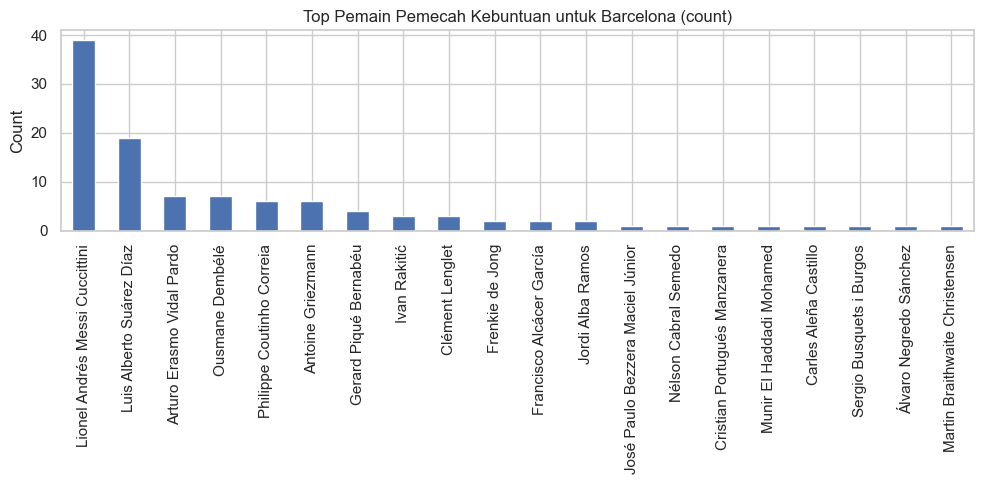

In [124]:
# Flexible detection of goal events & team column
team_col = None
for candidate in ['possession_team.name', 'team.name', 'team', 'possession_team']:
    if candidate in events_data.columns:
        team_col = candidate
        break

goal_col = None
if 'shot.outcome.name' in events_data.columns:
    goal_col = 'shot.outcome.name'
elif 'type.name' in events_data.columns:
    goal_col = 'type.name'

if team_col is None or goal_col is None or 'player.name' not in events_data.columns:
    print('Kolom yang dibutuhkan tidak lengkap di events_data. Diperlukan kolom: player.name, team identifier (possession_team.name atau team.name), dan kolom yang menandai goal (shot.outcome.name atau type.name).')
else:
    ev = events_data.copy().reset_index()
    ev['is_goal'] = ev[goal_col].astype(str).str.contains('goal', case=False, na=False)
    goals = ev[ev['is_goal']].copy()
    print(f'Terdapat {len(goals)} goal-event yang terdeteksi (berdasarkan kolom {goal_col}).')

    #display player.name,shot.outcome.name,team_col,match_id
    display(goals[['player.name', goal_col, team_col, 'match_id']].head(10))
    
    # Build timeline per match
    from collections import defaultdict
    scorer_counts = defaultdict(int)
    match_summaries = []

    for mid, gdf in goals.groupby('match_id'):
        gdf = gdf.sort_values('index')  # asumsi urutan kronologis sesuai index
        # Determine home/away team names from match_data
        row = match_data[match_data['match_id'] == mid]
        if row.empty:
            continue
        home = row.iloc[0].get('home_team.home_team_name', None)
        away = row.iloc[0].get('away_team.away_team_name', None)

        # track scores
        score = {home:0, away:0}
        # iterate goal events
        for _, evrow in gdf.iterrows():
            team = evrow[team_col]
            player = evrow.get('player.name', None)
            if pd.isna(team) or pd.isna(player):
                continue
            # before the goal
            opp = home if team == away else away
            team_before = score.get(team, 0)
            opp_before = score.get(opp, 0)
            # condition: previously trailing or tied
            if team_before <= opp_before:
                # count if this team is Barcelona (either home or away)
                if (str(team).lower() == 'barcelona') or (home == 'Barcelona' and team==home) or (away == 'Barcelona' and team==away):
                    scorer_counts[player] += 1
            # update score (assume goal increments by 1)
            score[team] = team_before + 1

    # Show top players
    scorer_series = pd.Series(scorer_counts).sort_values(ascending=False)
    print('\nTop pemain yang menjadi pemecah kebuntuan (hanya Barcelona):')
    if scorer_series.empty:
        print('Tidak ditemukan goal-event yang memenuhi kondisi atau kolom team names tidak konsisten.')
    else:
        display(scorer_series.head(20))
        scorer_series.head(20).plot(kind='bar', figsize=(10,5))
        plt.title('Top Pemain Pemecah Kebuntuan untuk Barcelona (count)')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

Distribusi kelas (Result_label):
Result_label
2    41
0    26
1    18
Name: count, dtype: int64

Persentase:
Result_label
2    48.235294
0    30.588235
1    21.176471
Name: proportion, dtype: float64
Using 25 numeric features for baseline. Showing first 20:
['home_score', 'away_score', 'match_week', 'Poss', 'duration_mean', 'duration_sum', 'duration_std', 'possession_max', 'possession_mean', 'under_pressure_sum', 'counterpress_sum', 'pass.outcome.name_<lambda>', 'shot.open_goal_sum', 'dribble.outcome.name_<lambda>', 'total_clearance_sum', 'foul_committed.penalty_sum', 'foul_won.penalty_sum', 'duel.outcome.positive_sum', 'interception.outcome.positive_sum', 'goalkeeper.outcome.positive_sum']

Baseline RandomForest (5-fold CV) accuracy:
[0.94117647 0.52941176 0.76470588 0.70588235 0.76470588]
Mean acc: 0.7411764705882353

Top 25 feature importances:


away_score                           0.137807
Poss                                 0.126388
home_score                           0.123675
duel.outcome.positive_sum            0.046139
counterpress_sum                     0.045891
duration_mean                        0.045356
duration_std                         0.041797
duration_sum                         0.036081
total_clearance_sum                  0.035931
match_week                           0.035518
shot.outcome.goal.barca              0.035234
shot.outcome.goal.nonbarca           0.034504
pass.outcome.name_<lambda>           0.033424
under_pressure_sum                   0.033107
interception.outcome.positive_sum    0.030276
dribble.outcome.name_<lambda>        0.029704
play_cluster                         0.024473
possession_mean                      0.024152
goalkeeper.outcome.positive_sum      0.022444
possession_max                       0.019509
shot.open_goal_sum                   0.012883
year                              

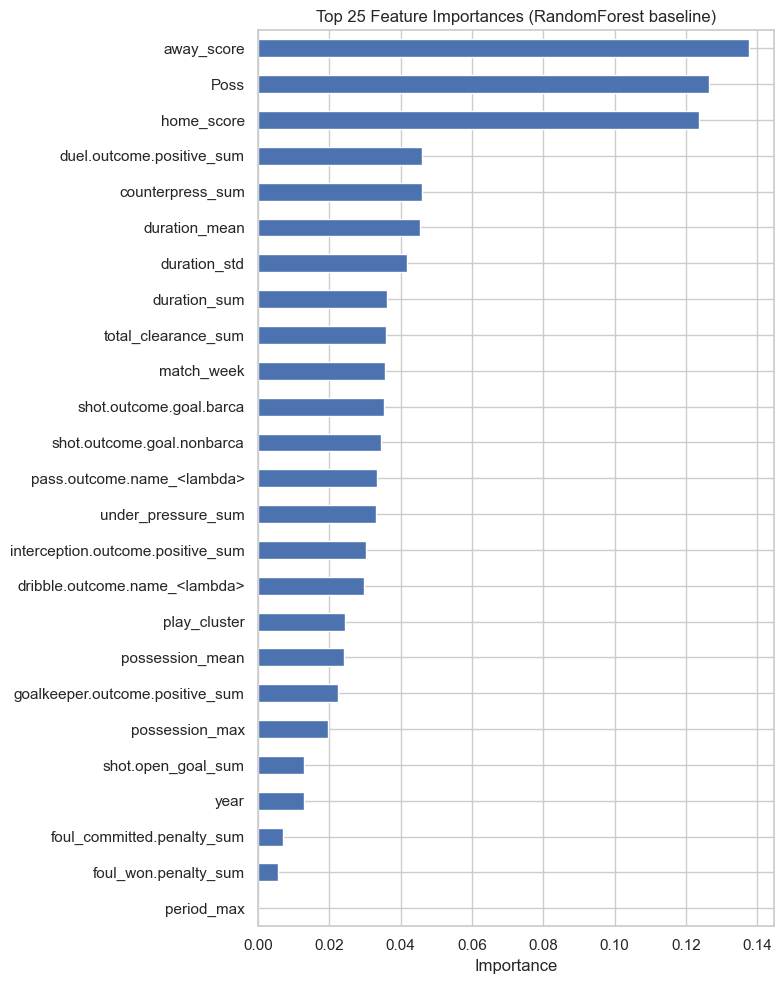

In [116]:
# === EDA (predictive) untuk memprediksi hasil tim kandang ===
# Pastikan df_merged tersedia (dibuat sebelumnya dari match_data + aggregated_features)
if 'df_merged' not in globals():
    print('df_merged belum ada di memori. Pastikan sel merge sudah dijalankan.')
else:
    # Buat salinan kecil untuk eksplorasi
    df = df_merged.copy()

    # Map Result ke numeric (Win=2, Draw=1, Lose=0)
    df['Result_label'] = df['Result'].map({'Win': 2, 'Draw': 1, 'Lose': 0})

    # Tampilkan distribusi kelas
    print('Distribusi kelas (Result_label):')
    print(df['Result_label'].value_counts())
    print('\nPersentase:')
    print(df['Result_label'].value_counts(normalize=True) * 100)

    # Pilih fitur numerik untuk baseline (exclude identifiers and target)
    exclude = ['match_id', 'match_date', 'kick_off', 'home_team.home_team_name', 'away_team.away_team_name',
               'stadium.name', 'referee.name', 'home_team.managers_name', 'away_team.managers_name',
               'Result', 'Result_label']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    features = [c for c in numeric_cols if c not in exclude]

    # If too many NaNs present, fill with 0 for aggregated features
    df[features] = df[features].fillna(0)

    print(f'Using {len(features)} numeric features for baseline. Showing first 20:')
    print(features[:20])

    # Quick baseline model: RandomForest
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    X = df[features].fillna(0)
    y = df['Result_label'].fillna(1).astype(int)

    # If dataset small or features empty, skip model
    if X.shape[0] < 10 or X.shape[1] == 0:
        print('Dataset terlalu kecil atau tidak ada fitur numerik terpilih untuk baseline.')
    else:
        clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
        print('\nBaseline RandomForest (5-fold CV) accuracy:')
        print(scores)
        print('Mean acc:', scores.mean())

        # Fit on full and get feature importances
        clf.fit(X, y)
        importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
        print('\nTop 25 feature importances:')
        display(importances.head(25))

        # Plot importances
        plt.figure(figsize=(8, 10))
        importances.head(25).sort_values().plot(kind='barh')
        plt.title('Top 25 Feature Importances (RandomForest baseline)')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()